# Class 3 - Feature Engineering

Yelp Restaurants Module 3 lab notebook. This notebook is organized for GitHub review and uses the final clean dataset produced by `scripts/run_pipeline.py`.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache" / "matplotlib"))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from yelp_lab.config import FINAL_SCHEMA

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "yelp_restaurants_clean.parquet"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "classes"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_DISPLAY_DIR = PROJECT_ROOT / ".cache" / "notebook_figures"
NOTEBOOK_DISPLAY_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
_display_counter = 0

def show_and_close():
    global _display_counter
    for number in plt.get_fignums():
        _display_counter += 1
        fig = plt.figure(number)
        display_path = NOTEBOOK_DISPLAY_DIR / f"figure_{_display_counter:03d}.png"
        fig.savefig(display_path, dpi=160, bbox_inches="tight")
        display(Image(filename=str(display_path)))
    plt.close("all")

plt.show = show_and_close

print(df.shape)
df.head()

(5852, 22)


,business_id,state,city,latitude,longitude,dist_from_center,n_categories,price_range_num,has_wifi,has_parking,...,alcohol_num,noise_level_num,hours_open_per_week,n_days_open,review_count,log_review_count,review_velocity,mean_review_length,mean_review_sentiment_score,stars
0,MTSW4McQd7CbVtyjqoe9mw,PA,Philadelphia,39.955505,-75.155564,0.882586,5,1,1,1,...,0,0,94.0,7,80,4.394449,6.374473,558.919540,2.160920,4.0
1,MUTTqe8uqyMdBl186RmNeA,PA,Philadelphia,39.953949,-75.143226,1.879011,3,2,1,1,...,2,2,53.0,6,245,5.505332,60.471854,647.640000,3.772000,4.0
2,ROeacJQwBeh05Rqg7F6TCg,PA,Philadelphia,39.943223,-75.162568,1.066541,2,1,0,1,...,0,1,54.0,6,205,5.327876,25.700947,432.432692,2.533654,4.5
3,QdN72BWoyFypdGJhhI5r7g,PA,Philadelphia,39.939825,-75.157447,1.566801,5,2,1,1,...,2,2,78.0,7,65,4.189655,20.932101,514.275362,2.826087,4.0
4,Mjboz24M9NlBeiOJKLEd_Q,PA,Philadelphia,40.022466,-75.218314,8.990560,4,1,0,0,...,0,2,41.0,6,41,3.737670,7.779351,470.146341,1.000000,3.0


## Goal

Create features that describe hours, geography, categories, and reviews.

Original PDF tasks:
- Compute `hours_open_per_week` and `n_days_open`.
- Compute Haversine distance from city center.
- Compute category counts.
- Read reviews in chunks and build review-based features.
- Make 3+ exploratory charts and 1 explanatory chart.

In [2]:
feature_cols = [
    "hours_open_per_week", "n_days_open", "dist_from_center",
    "n_categories", "review_velocity", "mean_review_length",
    "mean_review_sentiment_score"
]
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
hours_open_per_week,5852.0,59.207641,37.215799,0.000000,35.000000,65.000000,84.000000,168.000000
n_days_open,5852.0,5.369788,2.574601,0.000000,5.000000,7.000000,7.000000,7.000000
dist_from_center,5852.0,5.086489,5.376005,0.024284,1.235965,2.764969,7.830824,26.025132
n_categories,5852.0,4.650205,2.376211,1.000000,3.000000,4.000000,6.000000,36.000000
review_velocity,5852.0,17.331441,24.668360,0.421864,3.468303,8.500191,21.601509,362.746144
mean_review_length,5852.0,550.551315,169.316364,127.333333,439.230702,527.386422,635.138791,1767.480000
mean_review_sentiment_score,5852.0,2.019205,1.002647,-1.500000,1.428571,2.124655,2.685595,6.166667


## Exploratory Chart 1 - Hours Open Per Week

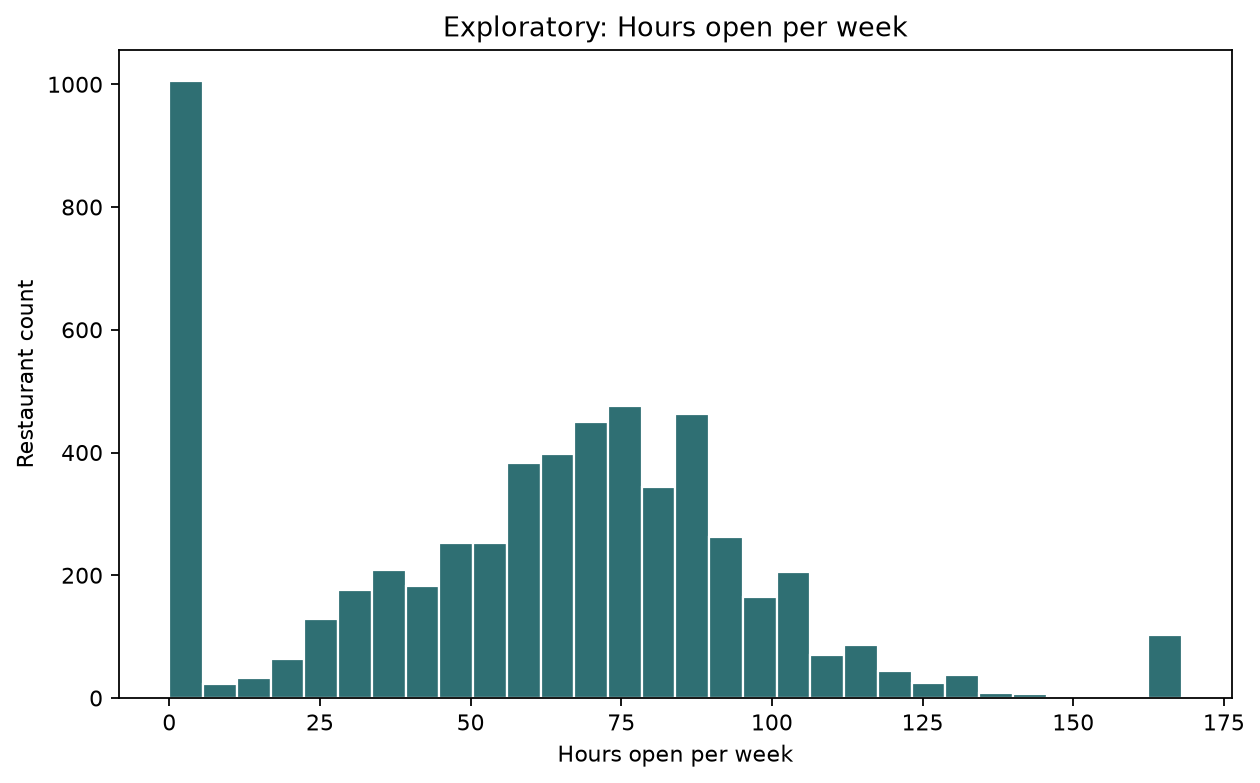

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["hours_open_per_week"], bins=30, color="#2f6f73", edgecolor="white")
ax.set_title("Exploratory: Hours open per week")
ax.set_xlabel("Hours open per week")
ax.set_ylabel("Restaurant count")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class3_exploratory_hours.png", dpi=160)
plt.show()

## Exploratory Chart 2 - Distance From City Center

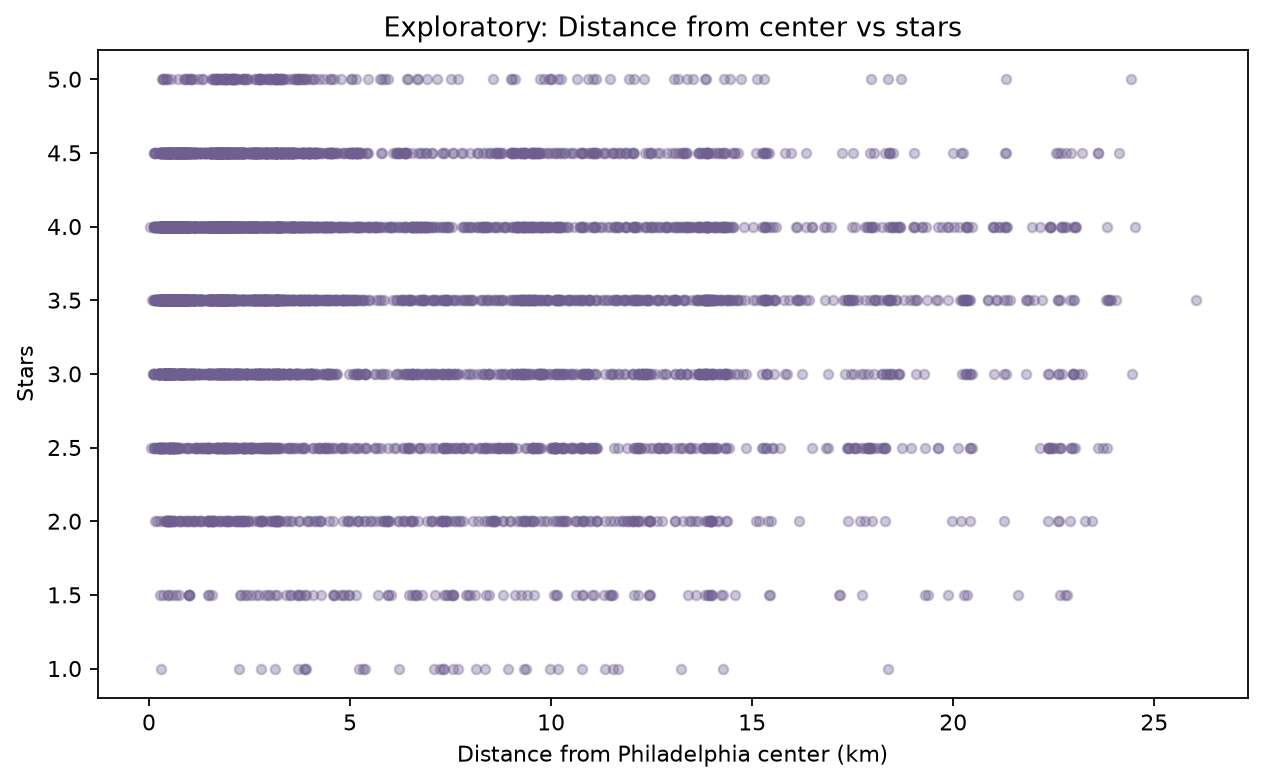

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["dist_from_center"], df["stars"], alpha=0.35, color="#6f5f90", s=18)
ax.set_title("Exploratory: Distance from center vs stars")
ax.set_xlabel("Distance from Philadelphia center (km)")
ax.set_ylabel("Stars")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class3_exploratory_distance.png", dpi=160)
plt.show()

## Exploratory Chart 3 - Review Sentiment Signal

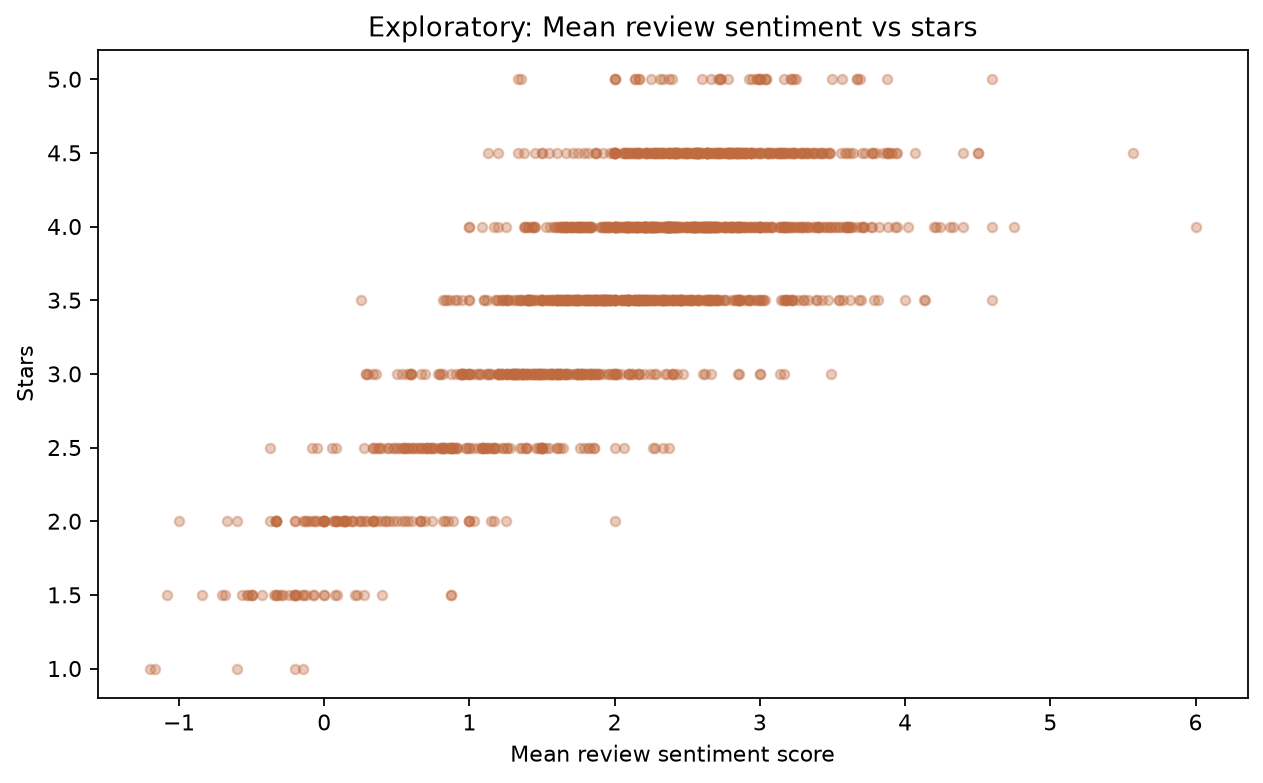

In [5]:
sample = df.sample(min(1500, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample["mean_review_sentiment_score"], sample["stars"], alpha=0.35, color="#bf6b3f", s=18)
ax.set_title("Exploratory: Mean review sentiment vs stars")
ax.set_xlabel("Mean review sentiment score")
ax.set_ylabel("Stars")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class3_exploratory_sentiment.png", dpi=160)
plt.show()

## Explanatory Chart for Priya - Hours Open and Star Ratings

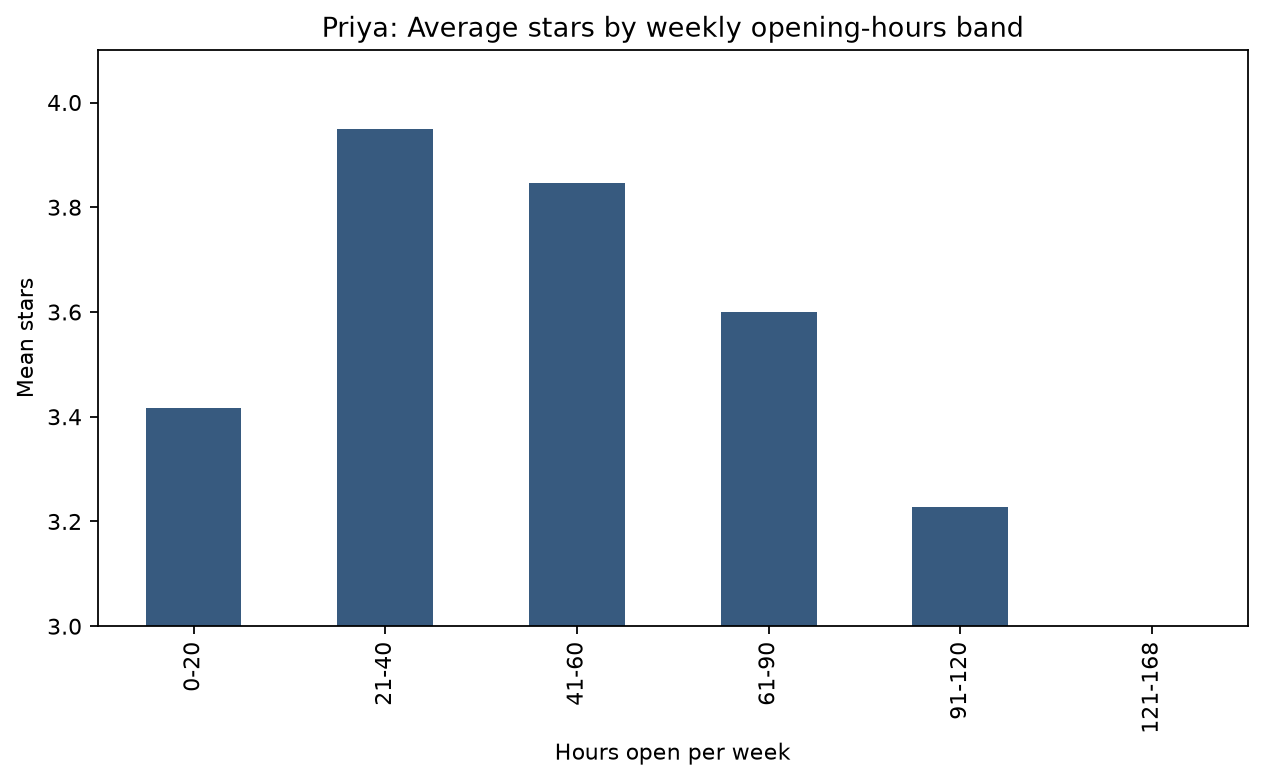

Takeaway: Hours matter, but they should be combined with location, metadata, and review signals.


In [6]:
hours_bins = pd.cut(
    df["hours_open_per_week"],
    bins=[-0.1, 20, 40, 60, 90, 120, 168],
    labels=["0-20", "21-40", "41-60", "61-90", "91-120", "121-168"],
)
hours_summary = df.groupby(hours_bins, observed=True)["stars"].mean()
fig, ax = plt.subplots(figsize=(8, 5))
hours_summary.plot(kind="bar", ax=ax, color="#375a7f")
ax.set_title("Priya: Average stars by weekly opening-hours band")
ax.set_xlabel("Hours open per week")
ax.set_ylabel("Mean stars")
ax.set_ylim(3.0, 4.1)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class3_explanatory_hours_vs_stars.png", dpi=160)
plt.show()
print("Takeaway: Hours matter, but they should be combined with location, metadata, and review signals.")

## Self-Check

- Hours features exist and are numeric.
- Distance from center exists.
- Category count exists.
- Review velocity, review length, and sentiment features exist.